# 5. Modelo CAPM, Frontera Eficiente y Línea de Mercado de Capitales

En este módulo construiremos una **frontera eficiente** utilizando la librería [PyPortfolioOpt](https://pyportfolioopt.readthedocs.io/en/latest/) con datos reales descargados de Yahoo Finance. Además, calcularemos:

- Los **pesos óptimos** del portafolio de máximo Sharpe y de mínima varianza.
- El **Beta (β)** de cada activo y del portafolio óptimo usando el modelo CAPM.
- La **Línea de Mercado de Capitales (CML)**, que conecta el activo libre de riesgo con el portafolio tangente.

## Conceptos clave

### Modelo CAPM

El modelo de valoración de activos de capital (CAPM) establece que el retorno esperado de un activo está en función de su riesgo sistemático:

$$E(R_i) = R_f + \beta_i \cdot (E(R_m) - R_f)$$

Donde:
- $R_f$: tasa libre de riesgo
- $\beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}$: sensibilidad del activo al mercado
- $E(R_m)$: retorno esperado del mercado

### Línea de Mercado de Capitales (CML)

La CML representa las combinaciones entre el activo libre de riesgo y el **portafolio tangente** (máximo Sharpe ratio):

$$E(R_p) = R_f + \frac{E(R_m) - R_f}{\sigma_m} \cdot \sigma_p$$

## 1. Importar librerías necesarias

Utilizaremos:
- `yfinance` para descargar datos de precios.
- `pypfopt` (PyPortfolioOpt) para la optimización del portafolio.
- `numpy`, `pandas` y `matplotlib` para cálculos y visualización.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pypfopt import expected_returns, risk_models, EfficientFrontier, CLA
from pypfopt import plotting

## 2. Descargar datos de Yahoo Finance

Seleccionaremos **5 acciones** representativas de distintos sectores, y el índice **S&P 500 (^GSPC)** como proxy del mercado:

| Ticker | Empresa | Sector |
|--------|---------|--------|
| AAPL | Apple | Tecnología |
| JNJ | Johnson & Johnson | Salud |
| JPM | JPMorgan Chase | Financiero |
| XOM | ExxonMobil | Energía |
| PG | Procter & Gamble | Consumo básico |

In [2]:
# Definir tickers de los 5 activos y el benchmark de mercado
tickers = ['AAPL', 'JNJ', 'JPM', 'XOM', 'PG']
benchmark = '^GSPC'  # S&P 500

# Descargar precios de cierre ajustados (3 años de historia)
datos = yf.download(tickers + [benchmark], start='2022-01-01', end='2025-01-01')['Close']
datos.dropna(inplace=True)

print(f"Período: {datos.index[0].date()} a {datos.index[-1].date()}")
print(f"Observaciones: {len(datos)}")
datos.head()

[*********************100%***********************]  6 of 6 completed

Período: 2022-01-03 a 2024-12-31
Observaciones: 753


Ticker,AAPL,JNJ,JPM,PG,XOM,^GSPC
Date,,,,,,
2022-01-03,178.103668,151.770050,144.929535,146.320892,54.760242,4796.560059
2022-01-04,175.843231,151.363052,150.423737,146.832886,56.819992,4793.540039
2022-01-05,171.165817,152.371689,147.673691,147.497589,57.526688,4700.580078
2022-01-06,168.308502,151.849670,149.242554,146.258041,58.879753,4696.049805
2022-01-07,168.474854,153.902283,150.721298,146.177170,59.362354,4677.029785


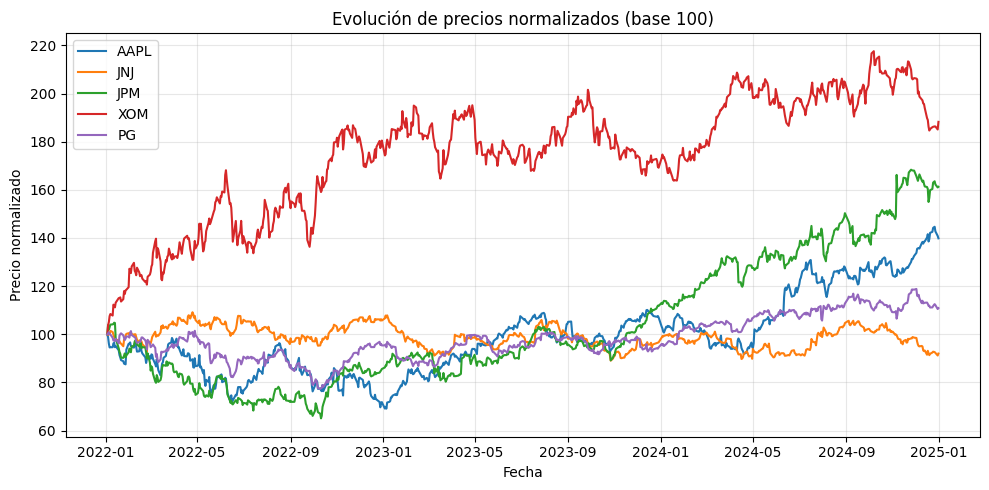

In [3]:
# Separar precios de los activos y del mercado
precios_activos = datos[tickers]
precios_mercado = datos[benchmark]

# Visualizar la evolución de precios normalizados (base 100)
precios_norm = precios_activos / precios_activos.iloc[0] * 100

plt.figure(figsize=(10, 5))
for col in precios_norm.columns:
    plt.plot(precios_norm.index, precios_norm[col], label=col)
plt.title('Evolución de precios normalizados (base 100)')
plt.xlabel('Fecha')
plt.ylabel('Precio normalizado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Calcular retornos y matriz de covarianza

Utilizaremos los métodos de PyPortfolioOpt para estimar:
- **Retornos esperados anualizados** usando la media histórica.
- **Matriz de covarianza** de los retornos mediante el estimador de muestra.

In [4]:
# Retornos esperados anualizados (media histórica)
mu = expected_returns.mean_historical_return(precios_activos)
print("Retornos esperados anualizados:")
print(mu.round(4))
print()

# Matriz de covarianza anualizada (estimador de muestra)
S = risk_models.sample_cov(precios_activos)
print("Matriz de covarianza anualizada:")
print(S.round(4))

Retornos esperados anualizados:
Ticker
AAPL    0.1189
JNJ    -0.0277
JPM     0.1736
XOM     0.2361
PG      0.0351
dtype: float64

Matriz de covarianza anualizada:
Ticker    AAPL     JNJ     JPM     XOM      PG
Ticker                                        
AAPL    0.0734  0.0082  0.0238  0.0125  0.0137
JNJ     0.0082  0.0268  0.0108  0.0053  0.0125
JPM     0.0238  0.0108  0.0625  0.0203  0.0093
XOM     0.0125  0.0053  0.0203  0.0741  0.0020
PG      0.0137  0.0125  0.0093  0.0020  0.0309


## 4. Optimización de portafolios con PyPortfolioOpt

### 4.1 Portafolio de Mínima Varianza

Es el portafolio con el menor riesgo posible, ubicado en el extremo izquierdo de la frontera eficiente.

In [5]:
# Portafolio de mínima varianza
ef_min_var = EfficientFrontier(mu, S)
ef_min_var.min_volatility()
pesos_min_var = ef_min_var.clean_weights()

print("Pesos del portafolio de mínima varianza:")
for ticker, peso in pesos_min_var.items():
    print(f"  {ticker}: {peso:.4f}")

ret_min, vol_min, sharpe_min = ef_min_var.portfolio_performance(verbose=True)

Pesos del portafolio de mínima varianza:
  AAPL: 0.0735
  JNJ: 0.3875
  JPM: 0.0723
  XOM: 0.1541
  PG: 0.3126
Expected annual return: 5.8%
Annual volatility: 12.8%
Sharpe Ratio: 0.45


### 4.2 Portafolio Tangente (Máximo Sharpe Ratio)

Es el portafolio que maximiza la relación retorno/riesgo. Es el punto donde la **CML** es tangente a la frontera eficiente.

$$\text{Sharpe Ratio} = \frac{E(R_p) - R_f}{\sigma_p}$$

Usaremos una tasa libre de riesgo del **5.0%** anual (aproximación del rendimiento de bonos del Tesoro de EE.UU.).

In [6]:
# Tasa libre de riesgo anual
rf = 0.05

# Portafolio de máximo Sharpe ratio (portafolio tangente)
ef_max_sharpe = EfficientFrontier(mu, S)
ef_max_sharpe.max_sharpe(risk_free_rate=rf)
pesos_tangente = ef_max_sharpe.clean_weights()

print("Pesos del portafolio tangente (máximo Sharpe):")
for ticker, peso in pesos_tangente.items():
    print(f"  {ticker}: {peso:.4f}")

ret_tan, vol_tan, sharpe_tan = ef_max_sharpe.portfolio_performance(risk_free_rate=rf, verbose=True)

Pesos del portafolio tangente (máximo Sharpe):
  AAPL: 0.0511
  JNJ: 0.0000
  JPM: 0.3421
  XOM: 0.6068
  PG: 0.0000
Expected annual return: 20.9%
Annual volatility: 21.2%
Sharpe Ratio: 0.75


## 5. Construcción de la Frontera Eficiente

Generamos múltiples portafolios óptimos a lo largo de la frontera eficiente usando el algoritmo CLA (Critical Line Algorithm) de PyPortfolioOpt.

In [7]:
# Generar puntos de la frontera eficiente usando simulación de Monte Carlo
np.random.seed(42)
n_portafolios = 10000
resultados = np.zeros((3, n_portafolios))

retornos_diarios = precios_activos.pct_change().dropna()
mu_array = mu.values
S_array = S.values

for i in range(n_portafolios):
    # Generar pesos aleatorios
    w = np.random.random(len(tickers))
    w = w / w.sum()
    
    # Retorno y volatilidad anualizados
    ret_p = np.dot(w, mu_array)
    vol_p = np.sqrt(np.dot(w.T, np.dot(S_array, w)))
    sharpe_p = (ret_p - rf) / vol_p
    
    resultados[0, i] = vol_p
    resultados[1, i] = ret_p
    resultados[2, i] = sharpe_p

# Convertir a DataFrame para facilitar la visualización
df_resultados = pd.DataFrame(resultados.T, columns=['Volatilidad', 'Retorno', 'Sharpe'])
print(f"Portafolios simulados: {n_portafolios}")
print(df_resultados.describe().round(4))

Portafolios simulados: 10000
       Volatilidad     Retorno      Sharpe
count   10000.0000  10000.0000  10000.0000
mean        0.1509      0.1079      0.3756
std         0.0128      0.0268      0.1555
min         0.1286      0.0038     -0.3289
25%         0.1416      0.0904      0.2804
50%         0.1488      0.1078      0.3903
75%         0.1578      0.1255      0.4875
max         0.2243      0.2033      0.7296


## 6. Cálculo del Beta (β) de cada activo

El Beta mide la sensibilidad de un activo frente al mercado. Se calcula como:

$$\beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}$$

- $\beta > 1$: El activo es más volátil que el mercado (agresivo).
- $\beta = 1$: Se mueve igual que el mercado.
- $\beta < 1$: El activo es menos volátil que el mercado (defensivo).

In [8]:
# Calcular retornos diarios de activos y mercado
retornos_activos = precios_activos.pct_change().dropna()
retornos_mercado = precios_mercado.pct_change().dropna()

# Alinear fechas
retornos_comunes = pd.concat([retornos_activos, retornos_mercado], axis=1).dropna()
retornos_comunes.columns = tickers + ['Mercado']

# Varianza del mercado
var_mercado = retornos_comunes['Mercado'].var()

# Calcular Beta de cada activo
betas = {}
for ticker in tickers:
    cov_con_mercado = retornos_comunes[ticker].cov(retornos_comunes['Mercado'])
    beta = cov_con_mercado / var_mercado
    betas[ticker] = beta

print("Beta (β) de cada activo:")
print("-" * 30)
for ticker, beta in betas.items():
    tipo = "Agresivo" if beta > 1 else "Defensivo" if beta < 1 else "Neutro"
    print(f"  {ticker}: β = {beta:.4f}  ({tipo})")

Beta (β) de cada activo:
------------------------------
  AAPL: β = 1.2107  (Agresivo)
  JNJ: β = 0.2466  (Defensivo)
  JPM: β = 0.8669  (Defensivo)
  XOM: β = 0.4651  (Defensivo)
  PG: β = 0.3731  (Defensivo)


### 6.1 Beta del Portafolio Tangente

El Beta del portafolio es el promedio ponderado de los betas individuales:

$$\beta_p = \sum_{i=1}^{n} w_i \cdot \beta_i$$

In [9]:
# Beta del portafolio tangente (máximo Sharpe)
pesos_tangente_array = np.array([pesos_tangente[t] for t in tickers])
beta_portafolio = sum(pesos_tangente[t] * betas[t] for t in tickers)

print("Beta del portafolio tangente:")
print(f"  β_p = {beta_portafolio:.4f}")
print()

# Retorno esperado del portafolio según CAPM
retorno_mercado_anual = retornos_comunes['Mercado'].mean() * 252
retorno_capm = rf + beta_portafolio * (retorno_mercado_anual - rf)
print(f"Retorno del mercado (anualizado): {retorno_mercado_anual:.4f}")
print(f"Retorno esperado del portafolio según CAPM: {retorno_capm:.4f}")
print(f"Retorno esperado del portafolio (histórico): {ret_tan:.4f}")

Beta del portafolio tangente:
  β_p = 0.6407

Retorno del mercado (anualizado): 0.0837
Retorno esperado del portafolio según CAPM: 0.0716
Retorno esperado del portafolio (histórico): 0.2087


### 6.2 Retorno esperado CAPM vs. histórico para cada activo

Comparamos el retorno que predice el CAPM con el retorno histórico observado:

In [10]:
# Tabla comparativa: Retorno CAPM vs Retorno Histórico
tabla_capm = pd.DataFrame({
    'Beta': [betas[t] for t in tickers],
    'Retorno CAPM': [rf + betas[t] * (retorno_mercado_anual - rf) for t in tickers],
    'Retorno Histórico': [mu[t] for t in tickers],
    'Peso Tangente': [pesos_tangente[t] for t in tickers]
}, index=tickers)

tabla_capm['Diferencia'] = tabla_capm['Retorno Histórico'] - tabla_capm['Retorno CAPM']
print(tabla_capm.round(4))

        Beta  Retorno CAPM  Retorno Histórico  Peso Tangente  Diferencia
AAPL  1.2107        0.0907             0.1189         0.0511      0.0282
JNJ   0.2466        0.0583            -0.0277         0.0000     -0.0860
JPM   0.8669        0.0792             0.1736         0.3421      0.0944
XOM   0.4651        0.0657             0.2361         0.6068      0.1704
PG    0.3731        0.0626             0.0351         0.0000     -0.0275


## 7. Gráfica Final: Frontera Eficiente + Línea de Mercado de Capitales (CML)

La gráfica integra:
1. **Nube de portafolios simulados** (Monte Carlo) coloreados por Sharpe Ratio.
2. **Frontera eficiente** optimizada usando CLA.
3. **Portafolio de mínima varianza** (punto rojo).
4. **Portafolio tangente** — máximo Sharpe (estrella dorada).
5. **Línea de Mercado de Capitales (CML)** que parte de $R_f$ y pasa por el portafolio tangente.
6. **Activos individuales** etiquetados con su Beta.

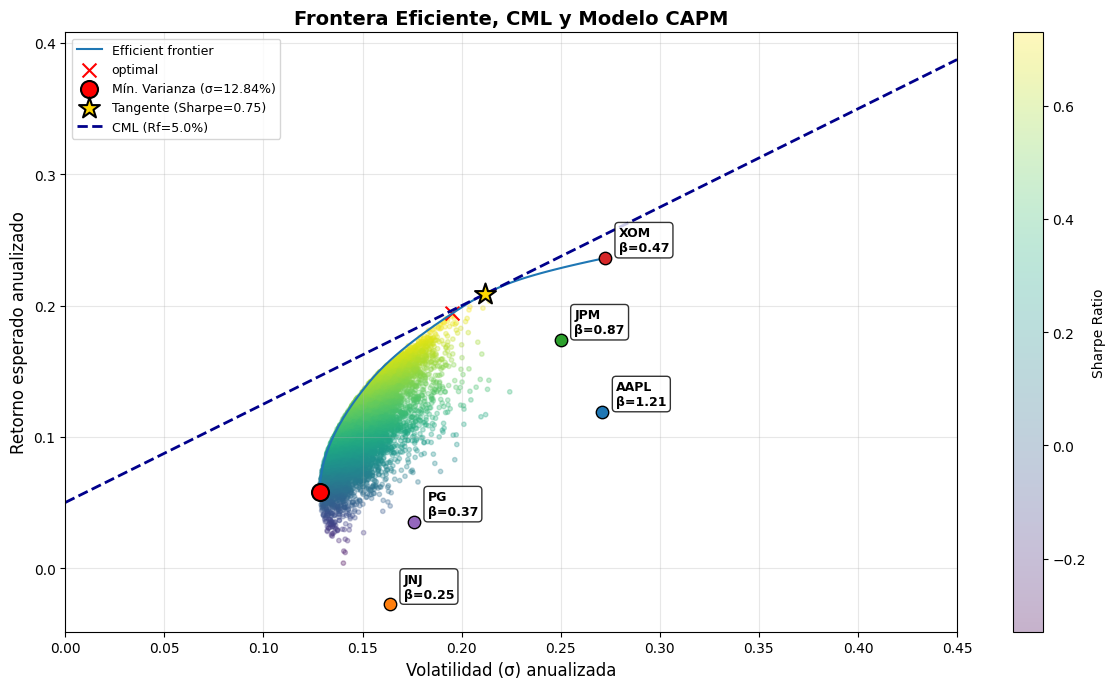

In [11]:
# --- GRÁFICA COMPLETA: Frontera Eficiente + CML + Activos + Beta ---

fig, ax = plt.subplots(figsize=(12, 7))

# 1. Nube de portafolios Monte Carlo
scatter = ax.scatter(
    df_resultados['Volatilidad'], df_resultados['Retorno'],
    c=df_resultados['Sharpe'], cmap='viridis', alpha=0.3, s=10
)
fig.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# 2. Frontera eficiente con CLA
cla = CLA(mu, S)
cla.max_sharpe()
ax = plotting.plot_efficient_frontier(cla, ax=ax, show_assets=False, 
                                       ef_param='risk', ef_param_range=np.linspace(vol_min, 0.45, 100))

# 3. Portafolio de mínima varianza
ax.scatter(vol_min, ret_min, color='red', s=150, zorder=5, 
           edgecolors='black', linewidths=1.5, label=f'Mín. Varianza (σ={vol_min:.2%})')

# 4. Portafolio tangente (máximo Sharpe)
ax.scatter(vol_tan, ret_tan, color='gold', s=250, marker='*', zorder=5,
           edgecolors='black', linewidths=1.5, label=f'Tangente (Sharpe={sharpe_tan:.2f})')

# 5. Línea de Mercado de Capitales (CML)
# La CML va desde Rf y tiene pendiente = Sharpe del portafolio tangente
vol_cml = np.linspace(0, 0.45, 100)
ret_cml = rf + sharpe_tan * vol_cml
ax.plot(vol_cml, ret_cml, color='darkblue', linewidth=2, linestyle='--', 
        label=f'CML (Rf={rf:.1%})')

# 6. Activos individuales etiquetados con Beta
for ticker in tickers:
    vol_i = np.sqrt(S.loc[ticker, ticker])
    ret_i = mu[ticker]
    beta_i = betas[ticker]
    ax.scatter(vol_i, ret_i, s=80, zorder=5, edgecolors='black', linewidths=1)
    ax.annotate(f'{ticker}\nβ={beta_i:.2f}', (vol_i, ret_i),
                textcoords='offset points', xytext=(10, 5),
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Configuración del gráfico
ax.set_title('Frontera Eficiente, CML y Modelo CAPM', fontsize=14, fontweight='bold')
ax.set_xlabel('Volatilidad (σ) anualizada', fontsize=12)
ax.set_ylabel('Retorno esperado anualizado', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 0.45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Gráfica Security Market Line (SML)

Mientras la CML grafica retorno vs volatilidad, la **Security Market Line (SML)** grafica retorno esperado vs Beta. Según el CAPM, todos los activos deben ubicarse sobre esta línea en equilibrio:

$$E(R_i) = R_f + \beta_i \cdot (E(R_m) - R_f)$$

- Activos **por encima** de la SML están subvalorados (ofrecen más retorno del que predice su riesgo).
- Activos **por debajo** de la SML están sobrevalorados.

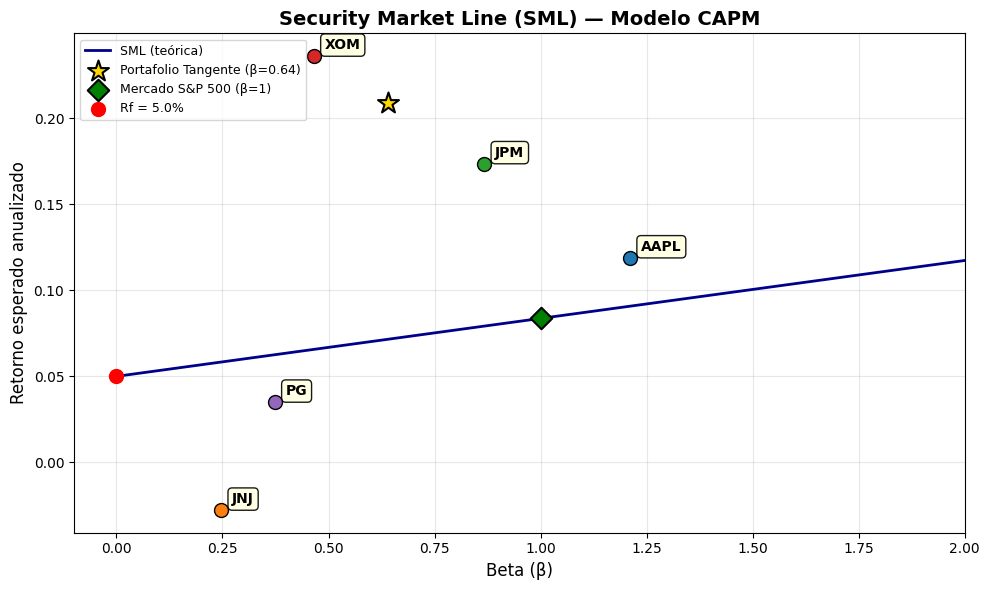

In [12]:
# --- GRÁFICA SML: Security Market Line ---
fig, ax = plt.subplots(figsize=(10, 6))

# Línea SML teórica
beta_range = np.linspace(0, 2, 100)
sml = rf + beta_range * (retorno_mercado_anual - rf)
ax.plot(beta_range, sml, color='darkblue', linewidth=2, label='SML (teórica)')

# Activos individuales (retorno histórico vs beta)
for ticker in tickers:
    ax.scatter(betas[ticker], mu[ticker], s=100, zorder=5, edgecolors='black', linewidths=1)
    ax.annotate(f'{ticker}', (betas[ticker], mu[ticker]),
                textcoords='offset points', xytext=(8, 5),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

# Portafolio tangente
ax.scatter(beta_portafolio, ret_tan, color='gold', s=250, marker='*', zorder=5,
           edgecolors='black', linewidths=1.5, label=f'Portafolio Tangente (β={beta_portafolio:.2f})')

# Mercado (β=1)
ax.scatter(1, retorno_mercado_anual, color='green', s=120, zorder=5, marker='D',
           edgecolors='black', linewidths=1.5, label=f'Mercado S&P 500 (β=1)')

# Tasa libre de riesgo
ax.scatter(0, rf, color='red', s=100, zorder=5, label=f'Rf = {rf:.1%}')

ax.set_title('Security Market Line (SML) — Modelo CAPM', fontsize=14, fontweight='bold')
ax.set_xlabel('Beta (β)', fontsize=12)
ax.set_ylabel('Retorno esperado anualizado', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.1, 2.0)
plt.tight_layout()
plt.show()

## Resumen

| Concepto | Descripción |
|----------|-------------|
| **Frontera Eficiente** | Conjunto de portafolios que maximizan el retorno para un nivel de riesgo dado |
| **Portafolio Tangente** | Portafolio con mayor Sharpe Ratio, punto de tangencia con la CML |
| **CML** | Línea que une $R_f$ con el portafolio tangente; representa las mejores combinaciones riesgo-retorno |
| **Beta (β)** | Mide el riesgo sistemático de un activo respecto al mercado |
| **SML** | Relación lineal entre Beta y retorno esperado según CAPM |
| **CAPM** | $E(R_i) = R_f + \beta_i(E(R_m) - R_f)$ |

### Conclusiones
- La **diversificación** permite reducir el riesgo no sistemático del portafolio.
- El **Sharpe Ratio** es la métrica clave para identificar el portafolio tangente.
- La **CML** nos indica que el portafolio óptimo de mercado combinado con el activo libre de riesgo domina a cualquier otro portafolio.
- El **Beta** del portafolio depende de la composición de activos: seleccionar activos defensivos ($\beta < 1$) reduce la exposición al riesgo de mercado.